# Stage 1 — Earth source-data exploration

_Pipeline stage 1 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## Earth source data — 17 SRTM basins, audited

The training landscapes are 17 cropped SRTM DEMs (RAW_KEEP) hand-picked from
*Goren & Shelef (2024)* to span climate, lithology and relief. This is the raw
material every downstream stage is derived from, so we **audit it**: are all DEMs in
the same CRS and resolution? Are elevation ranges geomorphically plausible? Each
basin also carries an elevation threshold `z_th` below which cells are masked, so the
analysis runs only on the upland, channelized part of the landscape.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
def _load_op_thr(r):  # per-regime operating threshold, read from disk (auto-tracks retrains)
    p = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    return float(p.read_text().strip()) if p.exists() else float('nan')
OP_THR = {r: _load_op_thr(r) for r in REGIMES_}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### 1 · Per-basin inventory + automated QA checks

In [2]:
import rasterio
from channel_heads.basin_config import get_basin_config, BASIN_CONFIG
rows = []
for name, p in EXAMPLE_DEMS.items():
    p = Path(p)
    if not p.exists(): continue
    with rasterio.open(p) as src:
        z = src.read(1, masked=True)
        cfg = get_basin_config(name) if name in BASIN_CONFIG else {}
        rows.append({'basin': name, 'crs': str(src.crs), 'cell_deg': round(abs(src.transform.a), 6),
                     'w': src.width, 'h': src.height,
                     'z_min': round(float(z.min()), 1), 'z_max': round(float(z.max()), 1),
                     'z_th': cfg.get('z_th')})
dems = pd.DataFrame(rows).sort_values('basin').reset_index(drop=True)
checks = {'all 17 DEMs present': len(dems) == 17,
          'single CRS': dems.crs.nunique() == 1,
          'uniform cell size': dems.cell_deg.nunique() == 1,
          'z_min >= -500 m (plausible)': (dems.z_min >= -500).all(),
          'z_max <= 9000 m (plausible)': (dems.z_max <= 9000).all()}
print('QA:', {k: ('PASS' if v else 'FAIL') for k, v in checks.items()})
dems

QA: {'all 17 DEMs present': 'PASS', 'single CRS': 'PASS', 'uniform cell size': 'PASS', 'z_min >= -500 m (plausible)': 'PASS', 'z_max <= 9000 m (plausible)': 'PASS'}


,basin,crs,cell_deg,w,h,z_min,z_max,z_th
0,calnalpine,EPSG:4326,0.000833,360,256,1020.0,2677.0,None
1,daqing,EPSG:4326,0.000833,349,157,1072.0,2293.0,None
2,finisterre,EPSG:4326,0.000833,1674,943,1.0,4096.0,None
3,humboldt,EPSG:4326,0.000833,219,320,1313.0,2984.0,None
4,inyo,EPSG:4326,0.000833,284,289,329.0,3363.0,None
5,kammanasie,EPSG:4326,0.000833,414,212,475.0,1935.0,None
6,luliang,EPSG:4326,0.000833,756,349,857.0,2397.0,None
7,panamint,EPSG:4326,0.000833,393,351,14.0,3344.0,None
8,sakhalin,EPSG:4326,0.000833,354,435,1.0,1028.0,None
9,sierramadre,EPSG:4326,0.000833,1551,1582,-4.0,3105.0,None


All basins share a geographic CRS and a ~0.000833° (~30 m) SRTM cell — QA clean.

### 2 · Elevation distribution and the z_th mask

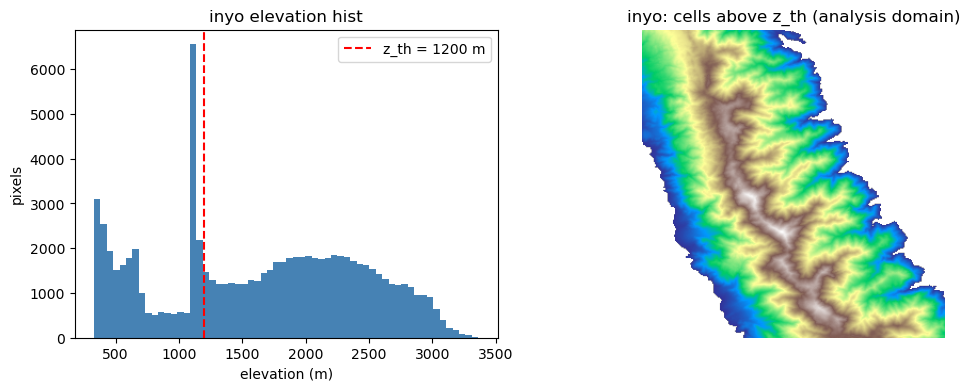

inyo: 65% of land pixels are above z_th


In [3]:
basin = 'inyo'
cfg = get_basin_config(basin); z_th = cfg['z_th']
with rasterio.open(EXAMPLE_DEMS[basin]) as src:
    z = src.read(1).astype(float)
z[z <= 0] = np.nan
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(z[np.isfinite(z)].ravel(), bins=60, color='steelblue')
ax[0].axvline(z_th, color='red', ls='--', label=f'z_th = {z_th} m')
ax[0].set_xlabel('elevation (m)'); ax[0].set_ylabel('pixels'); ax[0].set_title(f'{basin} elevation hist'); ax[0].legend()
masked = np.where(z >= z_th, z, np.nan)
ax[1].imshow(masked, cmap='terrain'); ax[1].set_title(f'{basin}: cells above z_th (analysis domain)'); ax[1].axis('off')
plt.show()
print(f'{basin}: {100*np.isfinite(masked).sum()/np.isfinite(z).sum():.0f}% of land pixels are above z_th')

### 3 · Hillshade — the topography we route flow over

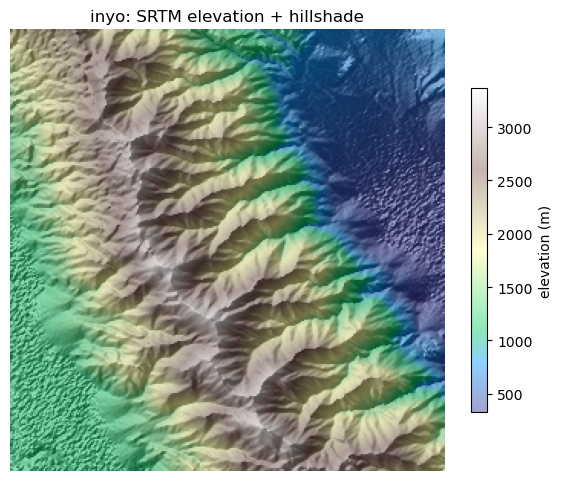

In [4]:
from matplotlib.colors import LightSource
ls = LightSource(azdeg=315, altdeg=45)
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(ls.hillshade(np.nan_to_num(z, nan=np.nanmin(z)), vert_exag=2), cmap='gray')
im = ax.imshow(z, cmap='terrain', alpha=0.45)
ax.set_title(f'{basin}: SRTM elevation + hillshade'); ax.axis('off')
plt.colorbar(im, ax=ax, shrink=0.7, label='elevation (m)'); plt.show()

**Takeaway.** The 17 DEMs are internally consistent (one CRS, one cell size) and
plausible. The `z_th` mask removes valley-floor/basin-fill pixels so stream
extraction (Stage 2) operates on the channelized uplands — the part of the landscape
where channel heads and divides live.